In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
input_csv = "/content/drive/MyDrive/CREATE Lab/video_agent360/features_person_slot0.csv"
df=pd.read_csv(input_csv)
df.head()

,frame_idx,t,face_detected,pose_detected,yaw_proxy,pitch_proxy,smile_score,mouth_open_score,left_wrist_x,left_wrist_y,right_wrist_x,right_wrist_y,left_wrist_vis,right_wrist_vis,left_elbow_y,right_elbow_y,left_shoulder_y,right_shoulder_y,left_wrist_speed,right_wrist_speed
0,0,0.000000,1,1,-0.057497,0.519073,0.278825,0.000337,0.757487,0.893516,0.387767,0.884817,0.962057,0.904021,0.788185,0.796503,0.645804,0.643382,NaN,NaN
1,1,0.068573,1,1,0.049977,0.537860,0.260075,0.003409,0.757570,0.894371,0.387086,0.884805,0.961785,0.908736,0.792723,0.818933,0.646995,0.650322,0.012520,0.009935
2,2,0.137146,1,1,0.086832,0.538086,0.265799,0.006043,0.757565,0.894409,0.387183,0.888227,0.962980,0.914336,0.797840,0.833551,0.648109,0.654350,0.000556,0.049931
3,3,0.205719,1,1,0.091030,0.554598,0.259694,0.005194,0.740058,0.883029,0.386403,0.888538,0.961414,0.913000,0.811772,0.840716,0.648222,0.657004,0.304501,0.012248
4,4,0.274292,1,1,0.125500,0.554111,0.262697,0.006194,0.706773,0.883450,0.397098,0.895335,0.900041,0.850794,0.841276,0.859912,0.648983,0.657268,0.485431,0.184798


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. Fill missing values
# =========================
for col in [
    "yaw_proxy", "pitch_proxy", "smile_score", "mouth_open_score",
    "left_wrist_x", "left_wrist_y", "right_wrist_x", "right_wrist_y",
    "left_wrist_speed", "right_wrist_speed"
]:
    if col in df.columns:
        df[col] = df[col].interpolate(limit_direction="both")

# =========================
# 2. Base behavior flags
# =========================
# Calibrated note-taking thresholds based on manually labeled note-taking intervals
LOOK_DOWN_THR = 0.69
LEFT_WRIST_BOTTOM_THR = 0.90
RIGHT_WRIST_BOTTOM_THR = 0.92

df["look_down_flag"] = df["pitch_proxy"] > LOOK_DOWN_THR
df["look_up_flag"] = df["pitch_proxy"] < 0.85
df["turn_left_flag"] = df["yaw_proxy"] < -0.08
df["turn_right_flag"] = df["yaw_proxy"] > 0.08

# smile / speaking
df["smiling_flag"] = df["smile_score"] > 0.42
df["speaking_like_flag"] = df["mouth_open_score"] > 0.08

# =========================
# 3. Improved note-taking detection
# =========================
# Writing in this video looks more like:
# - sustained downward head pose
# - at least one wrist staying near the lower desk area
# - relatively stable head posture over time
# rather than large wrist speed
df["hand_near_bottom"] = (
    (df["left_wrist_y"] > LEFT_WRIST_BOTTOM_THR) |
    (df["right_wrist_y"] > RIGHT_WRIST_BOTTOM_THR)
)

df["take_notes_raw"] = (
    df["look_down_flag"] &
    df["hand_near_bottom"]
)

# Head stability helps separate note-taking from quick nods / posture shifts
df["pitch_std"] = df["pitch_proxy"].rolling(30, min_periods=10).std()
df["stable_head"] = df["pitch_std"] < 0.03

# Require note-taking posture to persist for a short time window
df["take_notes_flag"] = (
    df["take_notes_raw"]
    .rolling(40, min_periods=10)
    .mean() > 0.65
) & df["stable_head"]

# Optional helper columns for later debugging / analysis
df["look_down_ratio_notes"] = (
    df["look_down_flag"].astype(int)
    .rolling(40, min_periods=10)
    .mean()
)
df["hand_bottom_ratio_notes"] = (
    df["hand_near_bottom"].astype(int)
    .rolling(40, min_periods=10)
    .mean()
)

# =========================
# 4. Improved nodding detection
# =========================
# Old version only used pitch_range > threshold, which can confuse:
# - sudden head raise
# - head lowering for note-taking
# - any large one-way head movement
#
# New version adds:
# 1) pitch must move enough inside a short window
# 2) pitch direction must reverse at least once (down->up or up->down)
# 3) exclude long sustained look-down windows
# 4) exclude note-taking windows
window = 15   # about 0.5s if fps ~= 30

df["pitch_diff"] = df["pitch_proxy"].diff()
df["pitch_sign"] = np.sign(df["pitch_diff"])

def sign_change_exists(x):
    x = np.array(x)
    x = x[~np.isnan(x)]
    x = x[x != 0]
    if len(x) < 2:
        return 0
    return int(np.any(x[:-1] * x[1:] < 0))

df["pitch_range"] = (
    df["pitch_proxy"].rolling(window, min_periods=5).max()
    - df["pitch_proxy"].rolling(window, min_periods=5).min()
)

df["pitch_sign_change"] = (
    df["pitch_sign"]
    .rolling(window, min_periods=5)
    .apply(sign_change_exists, raw=True)
)

df["look_down_ratio"] = (
    df["look_down_flag"].astype(int)
    .rolling(window, min_periods=5)
    .mean()
)

df["head_nodding_flag"] = (
    (df["pitch_range"] > 0.18) &
    (df["pitch_sign_change"] > 0) &
    (df["look_down_ratio"] < 0.80) &
    (~df["take_notes_flag"])
)

# =========================
# 5. Engagement score
# =========================
df["engagement_score"] = 0.0
df.loc[df["face_detected"] == 1, "engagement_score"] += 0.2
df.loc[df["pose_detected"] == 1, "engagement_score"] += 0.1
df.loc[df["head_nodding_flag"], "engagement_score"] += 0.2
df.loc[df["speaking_like_flag"], "engagement_score"] += 0.2
df.loc[df["smiling_flag"], "engagement_score"] += 0.1
df.loc[df["look_down_flag"], "engagement_score"] -= 0.1
df.loc[df["take_notes_flag"], "engagement_score"] += 0.1
df["engagement_score"] = df["engagement_score"].clip(0, 1)

# Quick sanity check
summary_cols = [
    "look_down_flag", "hand_near_bottom", "take_notes_raw",
    "stable_head", "take_notes_flag", "head_nodding_flag",
    "smiling_flag", "speaking_like_flag"
]
print(df[summary_cols].sum())


look_down_flag         6139
hand_near_bottom       8993
take_notes_raw         4950
stable_head           11711
take_notes_flag        4445
head_nodding_flag       221
smiling_flag            143
speaking_like_flag     2575
dtype: int64


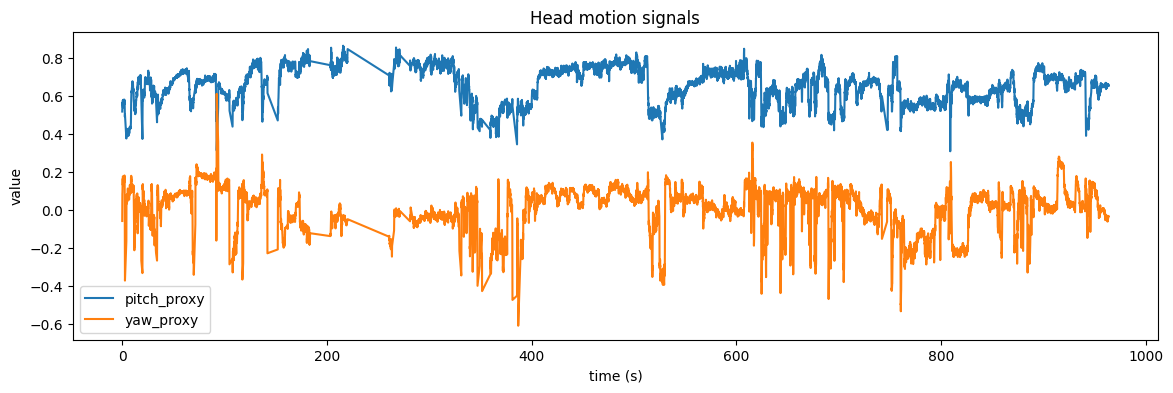

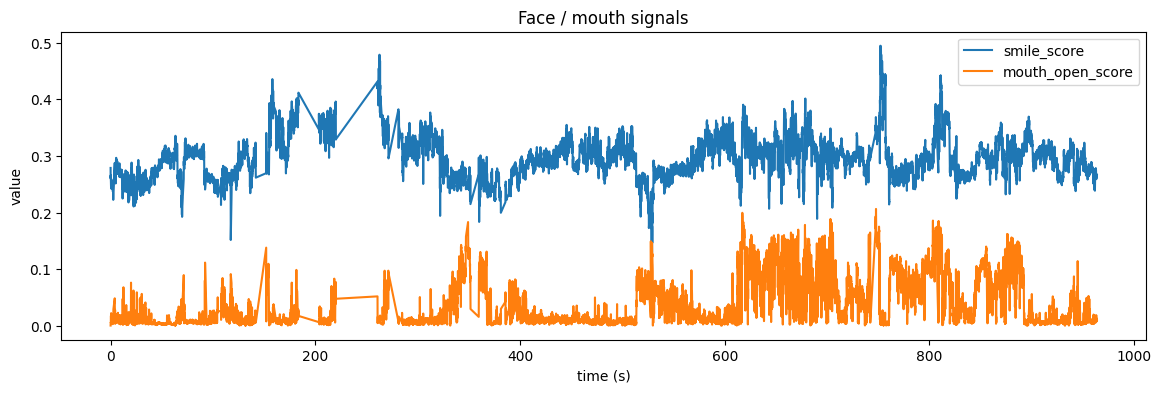

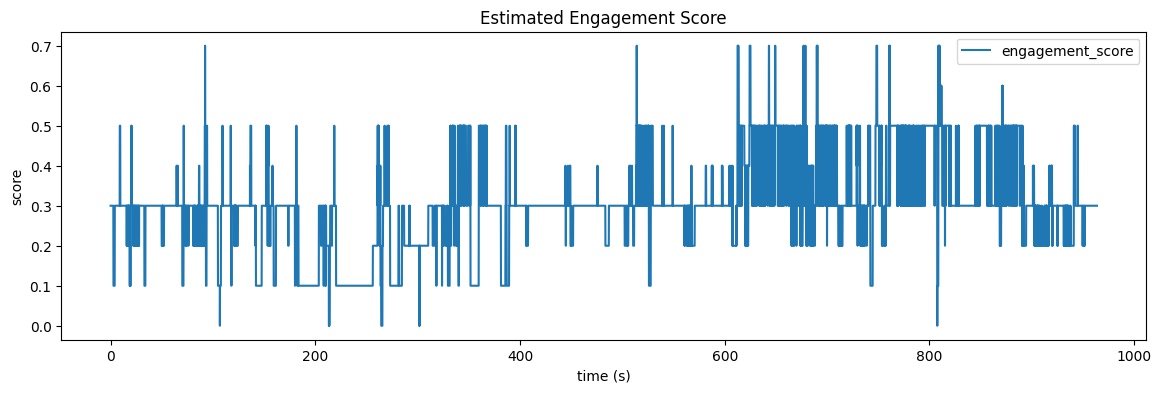

In [5]:

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["pitch_proxy"], label="pitch_proxy")
plt.plot(df["t"], df["yaw_proxy"], label="yaw_proxy")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("value")
plt.title("Head motion signals")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["smile_score"], label="smile_score")
plt.plot(df["t"], df["mouth_open_score"], label="mouth_open_score")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("value")
plt.title("Face / mouth signals")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["engagement_score"], label="engagement_score")
plt.xlabel("time (s)")
plt.ylabel("score")
plt.title("Estimated Engagement Score")
plt.legend()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def sec_to_mmss(x):
    if pd.isna(x):
        return "NA"
    m = int(x // 60)
    s = int(x % 60)
    return f"{m:02d}:{s:02d}"

time_col = "t"

behavior_cols = [
    "look_down_flag",
    "head_nodding_flag",
    "smiling_flag",
    "speaking_like_flag",
    "take_notes_flag"
]

behavior_names = {
    "look_down_flag": "look_down",
    "head_nodding_flag": "nodding",
    "smiling_flag": "smiling",
    "speaking_like_flag": "speaking_like",
    "take_notes_flag": "take_notes"
}

behavior_cols = [c for c in behavior_cols if c in df.columns]

plot_df = df.copy()
plot_df["time_str"] = plot_df[time_col].apply(sec_to_mmss)

def get_active_behaviors(row):
    active = []
    for col in behavior_cols:
        val = row[col]
        if pd.notna(val) and bool(val):
            active.append(behavior_names[col])
    return ", ".join(active) if active else "none"

plot_df["active_behaviors"] = plot_df.apply(get_active_behaviors, axis=1)

fig = go.Figure()

for i, col in enumerate(behavior_cols):
    y_vals = np.where(plot_df[col].fillna(False).astype(bool), i, np.nan)

    fig.add_trace(go.Scatter(
        x=plot_df[time_col],
        y=y_vals,
        mode="markers",
        name=behavior_names[col],
        customdata=plot_df[["time_str", "active_behaviors"]].values,
        hovertemplate=(
            "time: %{customdata[0]}<br>"
            "seconds: %{x:.2f}<br>"
            "active: %{customdata[1]}<br>"
            "<extra></extra>"
        ),
        marker=dict(size=7)
    ))

fig.update_layout(
    title="Interactive Behavior Timeline",
    xaxis_title="time (seconds)",
    yaxis=dict(
        tickmode="array",
        tickvals=list(range(len(behavior_cols))),
        ticktext=[behavior_names[c] for c in behavior_cols]
    ),
    hovermode="x unified",
    height=500,
    width=1400
)

fig.show()


In [7]:
output_csv = "video_agent360/features_with_behavior_slot0_v2.csv"
Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_csv, index=False)

print("saved to:", output_csv)
print(df.head())


saved to: video_agent360/features_with_behavior_slot0_v2.csv
   frame_idx         t  face_detected  pose_detected  yaw_proxy  pitch_proxy  \
0          0  0.000000              1              1  -0.057497     0.519073   
1          1  0.068573              1              1   0.049977     0.537860   
2          2  0.137146              1              1   0.086832     0.538086   
3          3  0.205719              1              1   0.091030     0.554598   
4          4  0.274292              1              1   0.125500     0.554111   

   smile_score  mouth_open_score  left_wrist_x  left_wrist_y  ...  \
0     0.278825          0.000337      0.757487      0.893516  ...   
1     0.260075          0.003409      0.757570      0.894371  ...   
2     0.265799          0.006043      0.757565      0.894409  ...   
3     0.259694          0.005194      0.740058      0.883029  ...   
4     0.262697          0.006194      0.706773      0.883450  ...   

   take_notes_flag  look_down_ratio_notes  